# HW12 — temporal split, baseline-модели и GRU-прогноз

В этом ноутбуке:
- загружается временной ряд из `S12-hw-dataset.csv`;
- выполняется корректный `temporal split` на `train / validation / test`;
- строятся baseline-модели `B1`, `B2`, `B3`;
- обучается `GRU`-модель `R1`;
- лучшая модель выбирается по `validation`;
- только один раз оценивается на `test`;
- сохраняются все обязательные артефакты и автоматически формируется `report.md`.

In [1]:
from pathlib import Path
import json
import math
import random
import sys
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

In [3]:
# Глобальные настройки
SEED = 42

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_PATH = Path("S12-hw-dataset.csv")
ARTIFACTS_DIR = Path("artifacts")
FIGURES_DIR = ARTIFACTS_DIR / "figures"
RUNS_PATH = ARTIFACTS_DIR / "runs.csv"
BEST_GRU_PATH = ARTIFACTS_DIR / "best_gru.pt"
BEST_GRU_CONFIG_PATH = ARTIFACTS_DIR / "best_gru_config.json"
REPORT_PATH = Path("report.md")

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Не найден файл {DATA_PATH}. Положи S12-hw-dataset.csv в папку homeworks/HW12/."
    )

HOURS_PER_DAY = 24
VAL_DAYS = 28
TEST_DAYS = 28

VAL_SIZE = VAL_DAYS * HOURS_PER_DAY
TEST_SIZE = TEST_DAYS * HOURS_PER_DAY

# Обязательные признаки из условия + полезные дополнительные признаки для hourly-series
LAG_FEATURES = [1, 7, 14, 24, 48, 168]
ROLLING_WINDOWS = [7, 24, 168]

# Окно для moving-average baseline
MA_WINDOW = 24

# Конфиг GRU
GRU_CONFIG = {
    "window_size": 168,      # одна неделя истории в часах
    "hidden_size": 32,
    "num_layers": 1,
    "dropout": 0.0,
    "batch_size": 128,
    "max_epochs": 15,
    "patience": 5,
    "lr": 1e-3,
    "optimizer": "Adam",
    "scaler": "StandardScaler(target_only_fit_on_train)",
}

print(f"SEED: {SEED}")
print(f"DEVICE: {DEVICE}")
print(f"DATA_PATH: {DATA_PATH.resolve()}")
print(f"ARTIFACTS_DIR: {ARTIFACTS_DIR.resolve()}")

SEED: 42
DEVICE: cpu
DATA_PATH: C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW12\S12-hw-dataset.csv
ARTIFACTS_DIR: C:\Users\andre\OneDrive\Документы\DPO\AIE\AIE-1\homeworks\HW12\artifacts


In [4]:
# Загрузка и sanity-check

df = pd.read_csv(DATA_PATH)

required_cols = {"date", "target"}
missing_required = required_cols - set(df.columns)
if missing_required:
    raise ValueError(f"В датасете нет обязательных колонок: {missing_required}")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").drop_duplicates(subset=["date"]).reset_index(drop=True)

if df["target"].isna().all():
    raise ValueError("Колонка target полностью пустая.")

n_obs = len(df)
date_min = df["date"].min()
date_max = df["date"].max()
missing_counts = df.isna().sum()

inferred_freq = pd.infer_freq(df["date"])
if inferred_freq is None:
    most_common_delta = df["date"].diff().dropna().mode().iloc[0]
    inferred_freq = f"manual_delta={most_common_delta}"

print("Форма датасета:", df.shape)
print("Диапазон дат:", date_min, "->", date_max)
print("Inferred frequency:", inferred_freq)
print("\nПропуски по колонкам:")
display(missing_counts.to_frame("missing_count"))

print("\nПервые строки:")
display(df.head())

print("\nОписательная статистика target:")
display(df["target"].describe().to_frame().T)

Форма датасета: (4320, 2)
Диапазон дат: 2025-01-01 00:00:00 -> 2025-06-29 23:00:00
Inferred frequency: h

Пропуски по колонкам:


,missing_count
date,0
target,0



Первые строки:


,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62



Описательная статистика target:


,count,mean,std,min,25%,50%,75%,max
target,4320.0,135.60584,21.384633,69.1,120.5375,135.835,150.625,210.1


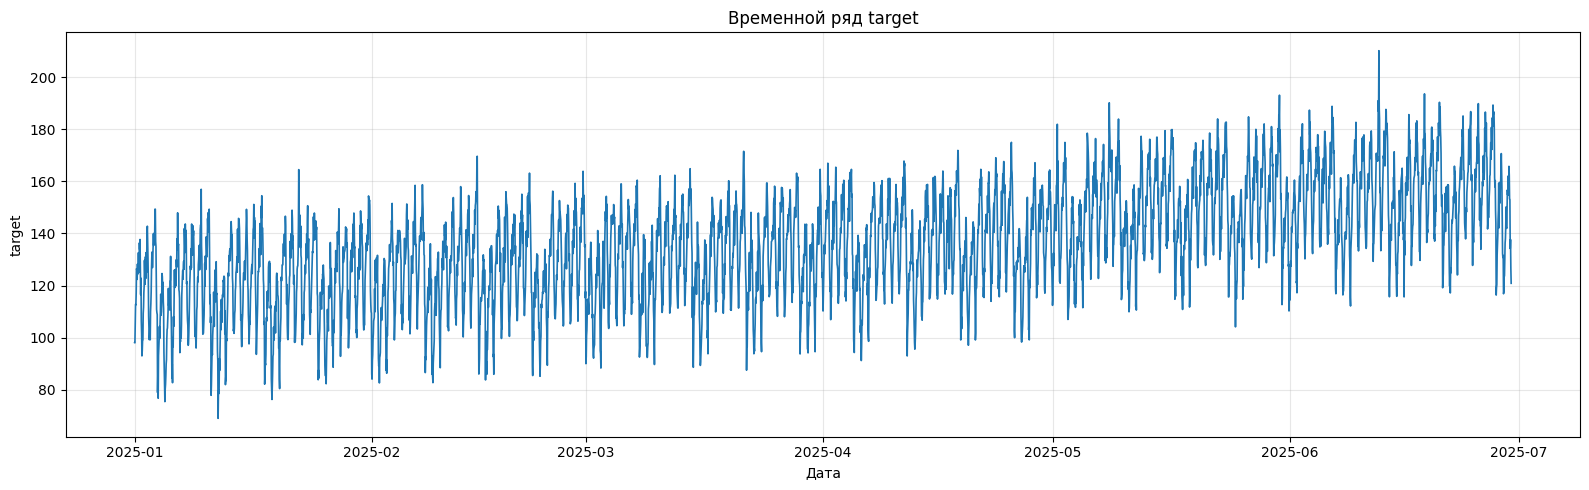

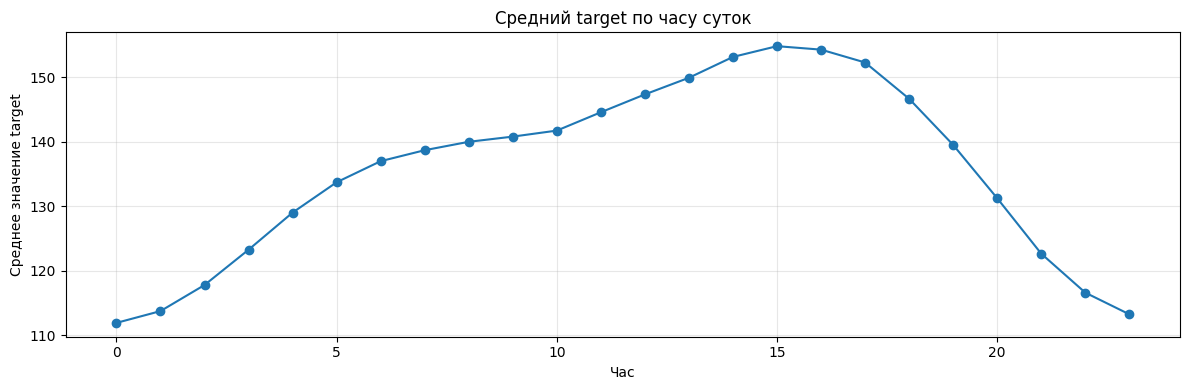

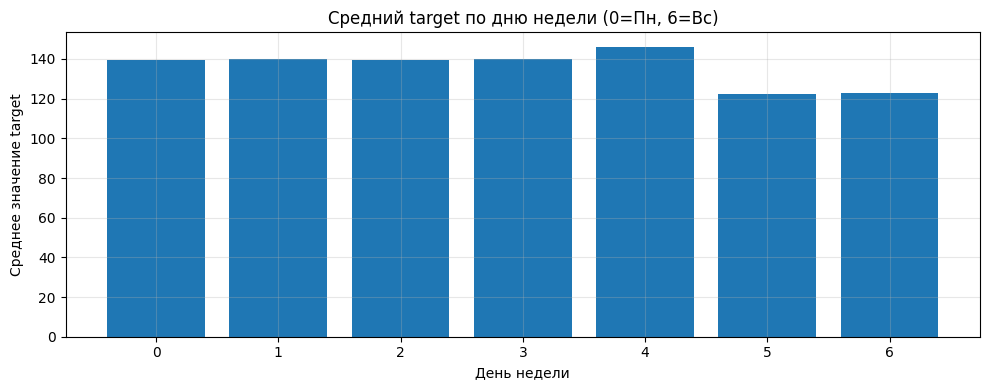

In [5]:
# Базовый график ряда

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df["date"], df["target"], linewidth=1.2)
ax.set_title("Временной ряд target")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Дополнительный быстрый взгляд на сезонность по часу и дню недели
tmp = df.copy()
tmp["hour"] = tmp["date"].dt.hour
tmp["day_of_week"] = tmp["date"].dt.dayofweek

hour_profile = tmp.groupby("hour")["target"].mean()
dow_profile = tmp.groupby("day_of_week")["target"].mean()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hour_profile.index, hour_profile.values, marker="o")
ax.set_title("Средний target по часу суток")
ax.set_xlabel("Час")
ax.set_ylabel("Среднее значение target")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(dow_profile.index.astype(str), dow_profile.values)
ax.set_title("Средний target по дню недели (0=Пн, 6=Вс)")
ax.set_xlabel("День недели")
ax.set_ylabel("Среднее значение target")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Комментарий по данным

Ниже выполняется **только хронологическое** разбиение на `train / validation / test`.
Для временных рядов случайное перемешивание строк некорректно, потому что модель в таком случае
получает доступ к будущему относительно части объектов и оценка становится слишком оптимистичной.

train: 2025-01-01 00:00:00 -> 2025-05-04 23:00:00 (2976 rows); val: 2025-05-05 00:00:00 -> 2025-06-01 23:00:00 (672 rows); test: 2025-06-02 00:00:00 -> 2025-06-29 23:00:00 (672 rows)


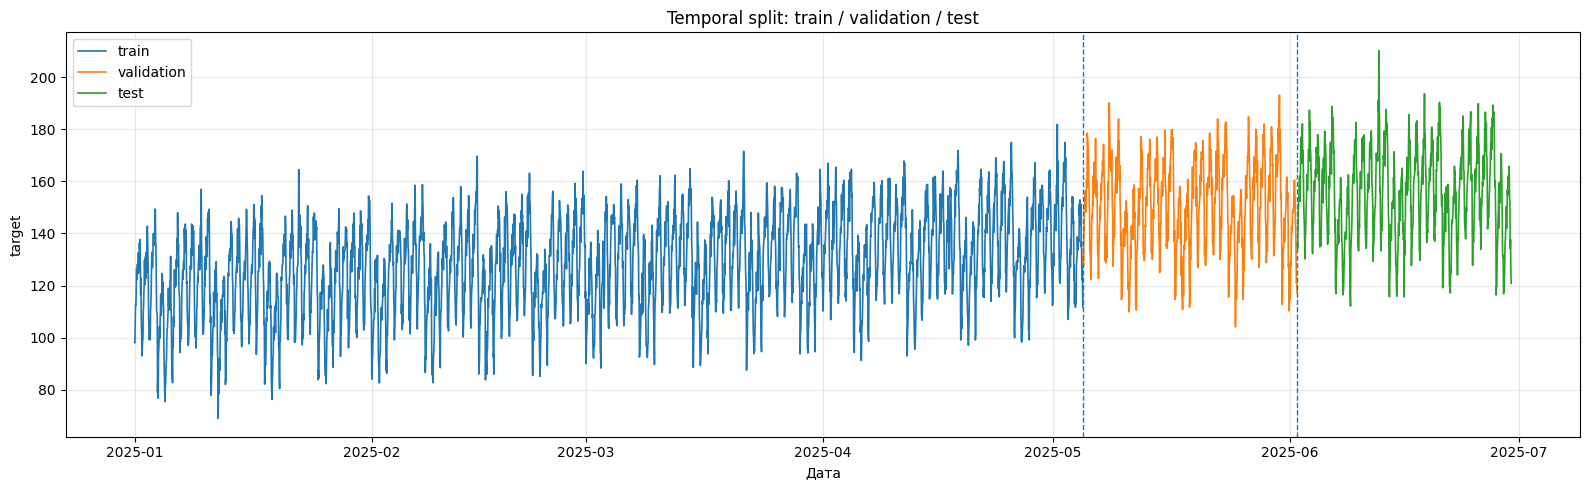

In [6]:
# Temporal split

if len(df) <= VAL_SIZE + TEST_SIZE:
    raise ValueError(
        f"Датасет слишком маленький для такого split. "
        f"Нужно больше {VAL_SIZE + TEST_SIZE} строк, а сейчас {len(df)}."
    )

train_size = len(df) - VAL_SIZE - TEST_SIZE
val_start_idx = train_size
test_start_idx = train_size + VAL_SIZE

train_df = df.iloc[:val_start_idx].copy()
val_df = df.iloc[val_start_idx:test_start_idx].copy()
test_df = df.iloc[test_start_idx:].copy()

train_start_date = train_df["date"].min()
train_end_date = train_df["date"].max()

val_start_date = val_df["date"].min()
val_end_date = val_df["date"].max()

test_start_date = test_df["date"].min()
test_end_date = test_df["date"].max()

split_summary = (
    f"train: {train_start_date} -> {train_end_date} ({len(train_df)} rows); "
    f"val: {val_start_date} -> {val_end_date} ({len(val_df)} rows); "
    f"test: {test_start_date} -> {test_end_date} ({len(test_df)} rows)"
)

print(split_summary)

# Визуализация split
fig, ax = plt.subplots(figsize=(16, 5))

ax.plot(train_df["date"], train_df["target"], label="train", linewidth=1.2)
ax.plot(val_df["date"], val_df["target"], label="validation", linewidth=1.2)
ax.plot(test_df["date"], test_df["target"], label="test", linewidth=1.2)

ax.axvline(val_start_date, linestyle="--", linewidth=1)
ax.axvline(test_start_date, linestyle="--", linewidth=1)

ax.set_title("Temporal split: train / validation / test")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "series_split.png", dpi=150, bbox_inches="tight")
plt.show()

## Вспомогательные функции

Ниже — единые функции для расчёта метрик и печати результатов.
Сравнение моделей будет идти по `validation`, а `test` будет использован только один раз
для финальной оценки лучшего подхода.

In [7]:
# Метрики и утилиты

def mape(y_true, y_pred, eps: float = 1e-8) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), eps))) * 100.0)

def compute_metrics(y_true, y_pred) -> dict:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(math.sqrt(mean_squared_error(y_true, y_pred))),
        "mape": float(mape(y_true, y_pred)),
    }

def print_metrics(name: str, metrics_dict: dict) -> None:
    print(
        f"{name}: "
        f"MAE={metrics_dict['mae']:.4f}, "
        f"RMSE={metrics_dict['rmse']:.4f}, "
        f"MAPE={metrics_dict['mape']:.4f}%"
    )

def make_run_row(
    experiment_id: str,
    model_summary: str,
    features_summary: str,
    scaler: str,
    optimizer: str,
    lr,
    epochs_trained,
    best_val_metrics: dict,
    notes: str = "",
):
    return {
        "experiment_id": experiment_id,
        "task": "forecasting",
        "dataset": DATA_PATH.name,
        "seed": SEED,
        "split_summary": split_summary,
        "window_size": GRU_CONFIG["window_size"] if experiment_id == "R1" else None,
        "horizon": 1,
        "model_summary": model_summary,
        "features_summary": features_summary,
        "scaler": scaler,
        "optimizer": optimizer,
        "lr": lr,
        "epochs_trained": epochs_trained,
        "best_val_mae": best_val_metrics["mae"],
        "best_val_rmse": best_val_metrics["rmse"],
        "best_val_mape": best_val_metrics["mape"],
        "test_mae": np.nan,
        "test_rmse": np.nan,
        "test_mape": np.nan,
        "notes": notes,
    }

In [8]:
# B1: naive-last
# B2: moving-average

df_baseline = df.copy()

# B1: прогноз = последнее известное значение
df_baseline["pred_b1_naive_last"] = df_baseline["target"].shift(1)

# B2: прогноз = среднее по последним MA_WINDOW наблюдениям
df_baseline["pred_b2_moving_avg"] = (
    df_baseline["target"]
    .shift(1)
    .rolling(MA_WINDOW)
    .mean()
)

# validation
val_b1_frame = df_baseline.iloc[val_start_idx:test_start_idx].dropna(subset=["pred_b1_naive_last"]).copy()
val_b2_frame = df_baseline.iloc[val_start_idx:test_start_idx].dropna(subset=["pred_b2_moving_avg"]).copy()

b1_val_metrics = compute_metrics(val_b1_frame["target"], val_b1_frame["pred_b1_naive_last"])
b2_val_metrics = compute_metrics(val_b2_frame["target"], val_b2_frame["pred_b2_moving_avg"])

print_metrics("B1 (validation)", b1_val_metrics)
print_metrics("B2 (validation)", b2_val_metrics)

# Сохраняем, чтобы потом при необходимости честно один раз посчитать test для лучшей модели
b1_test_frame = df_baseline.iloc[test_start_idx:].dropna(subset=["pred_b1_naive_last"]).copy()
b2_test_frame = df_baseline.iloc[test_start_idx:].dropna(subset=["pred_b2_moving_avg"]).copy()

B1 (validation): MAE=6.4480, RMSE=8.1961, MAPE=4.4037%
B2 (validation): MAE=13.3365, RMSE=16.1150, MAPE=9.1708%


In [9]:
# B3: Ridge на лаговых, rolling и календарных признаках

def build_feature_frame(raw_df: pd.DataFrame) -> pd.DataFrame:
    feat_df = raw_df.copy()

    # Лаги
    for lag in LAG_FEATURES:
        feat_df[f"lag_{lag}"] = feat_df["target"].shift(lag)

    # Rolling-признаки без утечки:
    # сначала shift(1), потом rolling(...)
    for window in ROLLING_WINDOWS:
        feat_df[f"rolling_mean_{window}"] = feat_df["target"].shift(1).rolling(window).mean()
        feat_df[f"rolling_std_{window}"] = feat_df["target"].shift(1).rolling(window).std()

    # Календарные признаки
    feat_df["day_of_week"] = feat_df["date"].dt.dayofweek
    feat_df["hour"] = feat_df["date"].dt.hour
    feat_df["day_of_month"] = feat_df["date"].dt.day
    feat_df["month"] = feat_df["date"].dt.month
    feat_df["is_weekend"] = feat_df["day_of_week"].isin([5, 6]).astype(int)

    return feat_df

df_feat = build_feature_frame(df)

feature_cols = [
    col for col in df_feat.columns
    if col.startswith("lag_") or col.startswith("rolling_")
] + ["day_of_week", "hour", "day_of_month", "month", "is_weekend"]

# После построения лагов и rolling будут NaN в начале
df_model = df_feat.dropna().reset_index(drop=True)

train_mask = df_model["date"] < val_start_date
val_mask = (df_model["date"] >= val_start_date) & (df_model["date"] < test_start_date)
test_mask = df_model["date"] >= test_start_date

X_train = df_model.loc[train_mask, feature_cols].copy()
y_train = df_model.loc[train_mask, "target"].copy()

X_val = df_model.loc[val_mask, feature_cols].copy()
y_val = df_model.loc[val_mask, "target"].copy()

X_test = df_model.loc[test_mask, feature_cols].copy()
y_test = df_model.loc[test_mask, "target"].copy()

feature_scaler = StandardScaler()
X_train_scaled = feature_scaler.fit_transform(X_train)
X_val_scaled = feature_scaler.transform(X_val)
X_test_scaled = feature_scaler.transform(X_test)

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)

ridge_val_pred = ridge_model.predict(X_val_scaled)
b3_val_metrics = compute_metrics(y_val, ridge_val_pred)
print_metrics("B3 (validation)", b3_val_metrics)

ridge_test_pred = ridge_model.predict(X_test_scaled)
ridge_test_dates = df_model.loc[test_mask, "date"].to_numpy()
ridge_test_true = y_test.to_numpy()

B3 (validation): MAE=5.5350, RMSE=6.9079, MAPE=3.6566%


In [10]:
# Подготовка оконного представления для GRU

window_size = GRU_CONFIG["window_size"]

if window_size >= len(train_df):
    raise ValueError(
        f"window_size={window_size} слишком велик для train-части длиной {len(train_df)}."
    )

target_scaler = StandardScaler()
target_scaler.fit(train_df[["target"]])

# ВАЖНО:
# scaler обучается только на train, а затем применяется ко всему ряду
series_all_scaled = target_scaler.transform(df[["target"]]).reshape(-1).astype(np.float32)

def inverse_target_scale(values) -> np.ndarray:
    values = np.asarray(values).reshape(-1, 1)
    return target_scaler.inverse_transform(values).reshape(-1)

class WindowDataset(Dataset):
    def __init__(self, scaled_series: np.ndarray, target_positions: np.ndarray, window_size: int):
        self.scaled_series = scaled_series
        self.target_positions = np.asarray(target_positions)
        self.window_size = window_size

    def __len__(self) -> int:
        return len(self.target_positions)

    def __getitem__(self, idx: int):
        target_pos = int(self.target_positions[idx])

        x_window = self.scaled_series[target_pos - self.window_size : target_pos]
        y_value = self.scaled_series[target_pos]

        x_window = torch.tensor(x_window.reshape(-1, 1), dtype=torch.float32)
        y_value = torch.tensor([y_value], dtype=torch.float32)

        return x_window, y_value

train_positions = np.arange(window_size, val_start_idx)
val_positions = np.arange(val_start_idx, test_start_idx)
test_positions = np.arange(test_start_idx, len(df))

train_dataset = WindowDataset(series_all_scaled, train_positions, window_size)
val_dataset = WindowDataset(series_all_scaled, val_positions, window_size)
test_dataset = WindowDataset(series_all_scaled, test_positions, window_size)

train_loader = DataLoader(
    train_dataset,
    batch_size=GRU_CONFIG["batch_size"],
    shuffle=True,
    num_workers=0,   # важно для Windows
)

val_loader = DataLoader(
    val_dataset,
    batch_size=GRU_CONFIG["batch_size"],
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=GRU_CONFIG["batch_size"],
    shuffle=False,
    num_workers=0,
)

print("Размер train_dataset:", len(train_dataset))
print("Размер val_dataset:", len(val_dataset))
print("Размер test_dataset:", len(test_dataset))

Размер train_dataset: 2808
Размер val_dataset: 672
Размер test_dataset: 672


In [11]:
# GRU-модель и функции обучения

class GRUForecaster(nn.Module):
    def __init__(
        self,
        input_size: int = 1,
        hidden_size: int = 32,
        num_layers: int = 1,
        dropout: float = 0.0,
    ):
        super().__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        output, _ = self.gru(x)
        last_hidden = output[:, -1, :]
        pred = self.head(last_hidden)
        return pred

def evaluate_gru(model: nn.Module, data_loader: DataLoader):
    model.eval()

    all_preds_scaled = []
    all_true_scaled = []
    losses = []

    criterion = nn.MSELoss()

    with torch.no_grad():
        for x_batch, y_batch in data_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            preds = model(x_batch)
            loss = criterion(preds, y_batch)

            losses.append(loss.item())
            all_preds_scaled.append(preds.detach().cpu().numpy().reshape(-1))
            all_true_scaled.append(y_batch.detach().cpu().numpy().reshape(-1))

    all_preds_scaled = np.concatenate(all_preds_scaled)
    all_true_scaled = np.concatenate(all_true_scaled)

    all_preds = inverse_target_scale(all_preds_scaled)
    all_true = inverse_target_scale(all_true_scaled)

    metrics = compute_metrics(all_true, all_preds)

    return {
        "loss": float(np.mean(losses)),
        "metrics": metrics,
        "preds": all_preds,
        "true": all_true,
    }

def train_gru(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, config: dict):
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"])
    criterion = nn.MSELoss()

    best_val_mae = float("inf")
    best_epoch = 0
    patience_counter = 0
    history = []

    for epoch in range(1, config["max_epochs"] + 1):
        model.train()
        train_losses = []

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            optimizer.zero_grad()
            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_result = evaluate_gru(model, val_loader)
        val_loss = val_result["loss"]
        val_metrics = val_result["metrics"]

        history.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "val_mae": val_metrics["mae"],
                "val_rmse": val_metrics["rmse"],
                "val_mape": val_metrics["mape"],
            }
        )

        print(
            f"Epoch {epoch:02d} | "
            f"train_loss={train_loss:.6f} | "
            f"val_loss={val_loss:.6f} | "
            f"val_mae={val_metrics['mae']:.6f}"
        )

        if val_metrics["mae"] < best_val_mae:
            best_val_mae = val_metrics["mae"]
            best_epoch = epoch
            patience_counter = 0

            torch.save(model.state_dict(), BEST_GRU_PATH)

            best_config_payload = {
                "seed": SEED,
                "device": str(DEVICE),
                "window_size": int(config["window_size"]),
                "hidden_size": int(config["hidden_size"]),
                "num_layers": int(config["num_layers"]),
                "dropout": float(config["dropout"]),
                "batch_size": int(config["batch_size"]),
                "max_epochs": int(config["max_epochs"]),
                "patience": int(config["patience"]),
                "optimizer": config["optimizer"],
                "lr": float(config["lr"]),
                "scaler": config["scaler"],
                "best_epoch": int(best_epoch),
                "best_val_mae": float(best_val_mae),
                "split_summary": split_summary,
                "dataset": DATA_PATH.name,
            }

            with open(BEST_GRU_CONFIG_PATH, "w", encoding="utf-8") as f:
                json.dump(best_config_payload, f, ensure_ascii=False, indent=2)

        else:
            patience_counter += 1

        if patience_counter >= config["patience"]:
            print(f"Early stopping: patience={config['patience']} исчерпана.")
            break

    history_df = pd.DataFrame(history)

    # Загружаем лучший checkpoint
    model.load_state_dict(torch.load(BEST_GRU_PATH, map_location=DEVICE))
    return model, history_df

Epoch 01 | train_loss=0.817193 | val_loss=1.343519 | val_mae=18.719489
Epoch 02 | train_loss=0.574568 | val_loss=0.746677 | val_mae=13.963313
Epoch 03 | train_loss=0.406425 | val_loss=0.497421 | val_mae=11.294362
Epoch 04 | train_loss=0.276036 | val_loss=0.381639 | val_mae=9.783411
Epoch 05 | train_loss=0.204335 | val_loss=0.300136 | val_mae=8.481781
Epoch 06 | train_loss=0.174054 | val_loss=0.219882 | val_mae=7.162189
Epoch 07 | train_loss=0.164412 | val_loss=0.227400 | val_mae=7.309375
Epoch 08 | train_loss=0.160034 | val_loss=0.219286 | val_mae=7.165009
Epoch 09 | train_loss=0.156334 | val_loss=0.214525 | val_mae=7.086993
Epoch 10 | train_loss=0.153978 | val_loss=0.210942 | val_mae=7.016641
Epoch 11 | train_loss=0.150918 | val_loss=0.201345 | val_mae=6.796277
Epoch 12 | train_loss=0.150767 | val_loss=0.201467 | val_mae=6.812947
Epoch 13 | train_loss=0.148372 | val_loss=0.209262 | val_mae=6.952874
Epoch 14 | train_loss=0.147518 | val_loss=0.206784 | val_mae=6.938003
Epoch 15 | train_

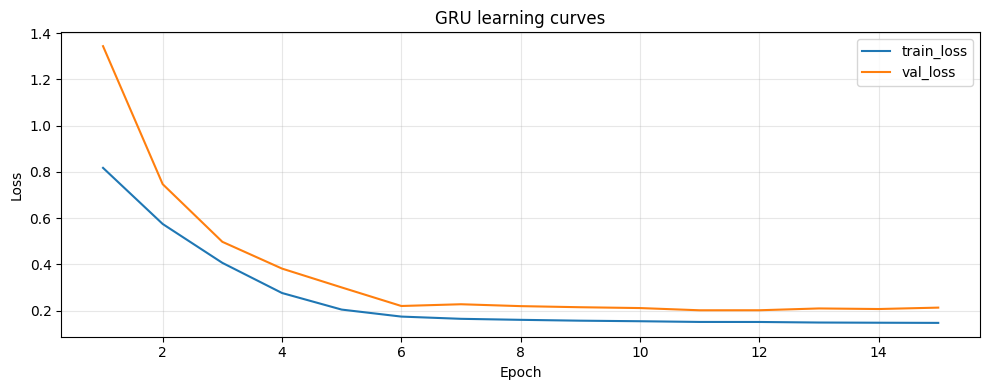

In [12]:
# Обучение R1 = GRU

gru_model = GRUForecaster(
    input_size=1,
    hidden_size=GRU_CONFIG["hidden_size"],
    num_layers=GRU_CONFIG["num_layers"],
    dropout=GRU_CONFIG["dropout"],
).to(DEVICE)

gru_model, gru_history = train_gru(gru_model, train_loader, val_loader, GRU_CONFIG)

r1_val_result = evaluate_gru(gru_model, val_loader)
r1_val_metrics = r1_val_result["metrics"]
print_metrics("R1 (validation)", r1_val_metrics)

# Кривые обучения
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(gru_history["epoch"], gru_history["train_loss"], label="train_loss")
ax.plot(gru_history["epoch"], gru_history["val_loss"], label="val_loss")
ax.set_title("GRU learning curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gru_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

,experiment_id,best_val_mae,best_val_rmse,best_val_mape
2,B3,5.534963,6.907851,3.656590
0,B1,6.448006,8.196078,4.403651
3,R1,6.796277,8.451473,4.563544
1,B2,13.336477,16.114967,9.170757


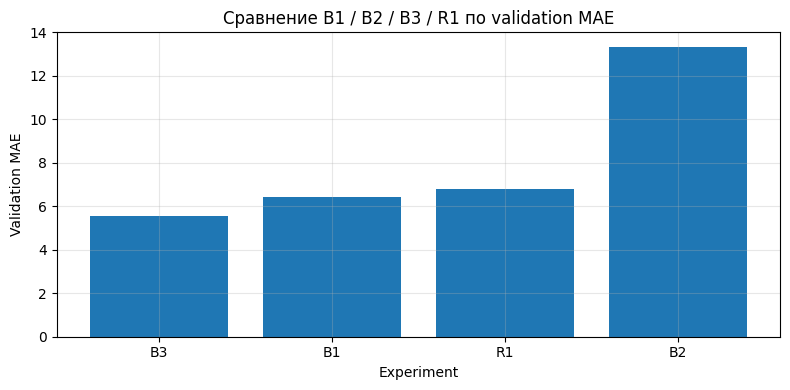

Промежуточный runs.csv сохранён: artifacts\runs.csv


In [13]:
# Сводка validation-результатов

runs = []

runs.append(
    make_run_row(
        experiment_id="B1",
        model_summary="naive-last",
        features_summary="last observed value only",
        scaler="none",
        optimizer="none",
        lr=None,
        epochs_trained=None,
        best_val_metrics=b1_val_metrics,
        notes="Baseline without training. Test kept empty until final model selection.",
    )
)

runs.append(
    make_run_row(
        experiment_id="B2",
        model_summary=f"moving-average(window={MA_WINDOW})",
        features_summary=f"rolling average of previous {MA_WINDOW} observations",
        scaler="none",
        optimizer="none",
        lr=None,
        epochs_trained=None,
        best_val_metrics=b2_val_metrics,
        notes="Baseline without training. Test kept empty until final model selection.",
    )
)

runs.append(
    make_run_row(
        experiment_id="B3",
        model_summary="Ridge(alpha=1.0)",
        features_summary=", ".join(feature_cols),
        scaler="StandardScaler(features_fit_on_train_only)",
        optimizer="closed-form/solver-internal",
        lr=None,
        epochs_trained=None,
        best_val_metrics=b3_val_metrics,
        notes="Lag, rolling and calendar features. Test kept empty until final model selection.",
    )
)

runs.append(
    make_run_row(
        experiment_id="R1",
        model_summary=(
            f"GRU(hidden_size={GRU_CONFIG['hidden_size']}, "
            f"num_layers={GRU_CONFIG['num_layers']}, "
            f"window_size={GRU_CONFIG['window_size']})"
        ),
        features_summary="raw target windows only",
        scaler=GRU_CONFIG["scaler"],
        optimizer=GRU_CONFIG["optimizer"],
        lr=GRU_CONFIG["lr"],
        epochs_trained=len(gru_history),
        best_val_metrics=r1_val_metrics,
        notes="Best checkpoint saved by validation MAE. Test kept empty until final model selection.",
    )
)

runs_df = pd.DataFrame(runs)
display(runs_df[["experiment_id", "best_val_mae", "best_val_rmse", "best_val_mape"]].sort_values("best_val_mae"))

# График сравнения подходов на validation
compare_df = runs_df[["experiment_id", "best_val_mae"]].sort_values("best_val_mae")

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(compare_df["experiment_id"], compare_df["best_val_mae"])
ax.set_title("Сравнение B1 / B2 / B3 / R1 по validation MAE")
ax.set_xlabel("Experiment")
ax.set_ylabel("Validation MAE")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "baselines_compare.png", dpi=150, bbox_inches="tight")
plt.show()

# Пока сохраняем без test-метрик
runs_df.to_csv(RUNS_PATH, index=False)
print(f"Промежуточный runs.csv сохранён: {RUNS_PATH}")

Лучшая модель по validation: B3
B3 (test): MAE=5.1216, RMSE=6.3780, MAPE=3.2587%


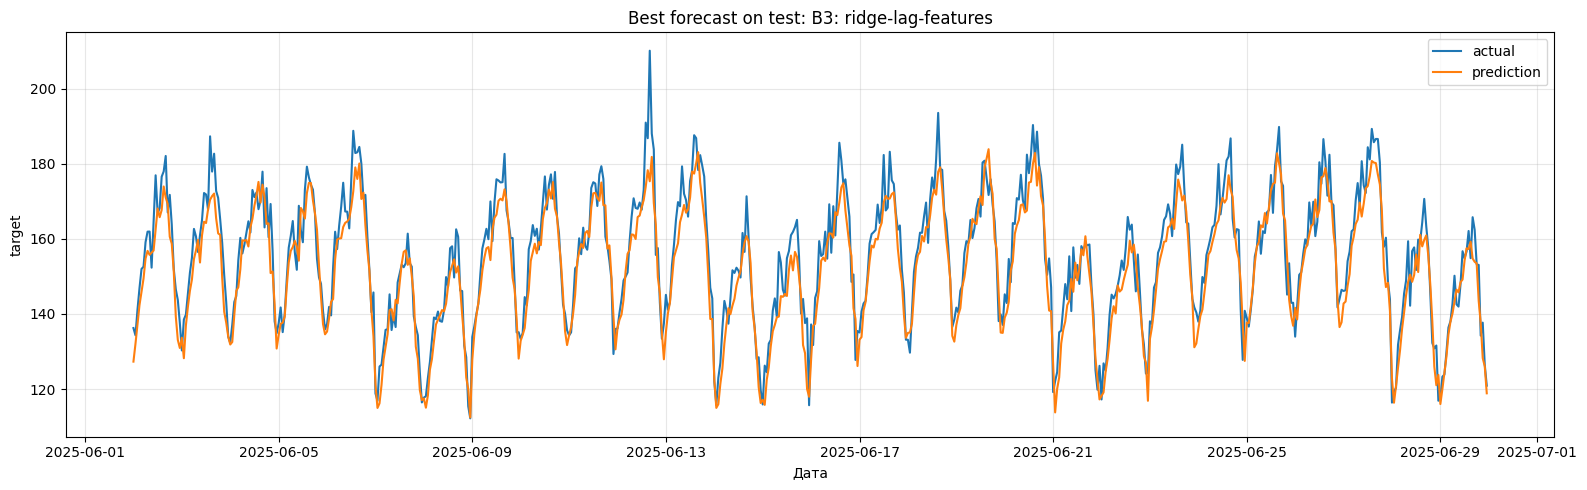

Финальный runs.csv сохранён: artifacts\runs.csv


In [14]:
# Выбор лучшей модели по validation
# И ТОЛЬКО ОДИН РАЗ оценка на test

best_experiment_id = runs_df.sort_values("best_val_mae").iloc[0]["experiment_id"]
print("Лучшая модель по validation:", best_experiment_id)

best_test_dates = None
best_test_true = None
best_test_pred = None
best_test_metrics = None
best_model_title = None

if best_experiment_id == "B1":
    best_test_dates = b1_test_frame["date"].to_numpy()
    best_test_true = b1_test_frame["target"].to_numpy()
    best_test_pred = b1_test_frame["pred_b1_naive_last"].to_numpy()
    best_test_metrics = compute_metrics(best_test_true, best_test_pred)
    best_model_title = "B1: naive-last"

elif best_experiment_id == "B2":
    best_test_dates = b2_test_frame["date"].to_numpy()
    best_test_true = b2_test_frame["target"].to_numpy()
    best_test_pred = b2_test_frame["pred_b2_moving_avg"].to_numpy()
    best_test_metrics = compute_metrics(best_test_true, best_test_pred)
    best_model_title = f"B2: moving-average(window={MA_WINDOW})"

elif best_experiment_id == "B3":
    best_test_dates = ridge_test_dates
    best_test_true = ridge_test_true
    best_test_pred = ridge_test_pred
    best_test_metrics = compute_metrics(best_test_true, best_test_pred)
    best_model_title = "B3: ridge-lag-features"

elif best_experiment_id == "R1":
    r1_test_result = evaluate_gru(gru_model, test_loader)
    best_test_dates = df.iloc[test_start_idx:]["date"].to_numpy()
    best_test_true = r1_test_result["true"]
    best_test_pred = r1_test_result["preds"]
    best_test_metrics = r1_test_result["metrics"]
    best_model_title = "R1: gru-forecast"

else:
    raise ValueError(f"Неизвестный experiment_id: {best_experiment_id}")

print_metrics(f"{best_experiment_id} (test)", best_test_metrics)

# Обновляем runs.csv:
# только у лучшей модели пишем test-метрики, у остальных оставляем пусто
runs_df.loc[runs_df["experiment_id"] == best_experiment_id, "test_mae"] = best_test_metrics["mae"]
runs_df.loc[runs_df["experiment_id"] == best_experiment_id, "test_rmse"] = best_test_metrics["rmse"]
runs_df.loc[runs_df["experiment_id"] == best_experiment_id, "test_mape"] = best_test_metrics["mape"]

runs_df.loc[runs_df["experiment_id"] == best_experiment_id, "notes"] = (
    str(runs_df.loc[runs_df["experiment_id"] == best_experiment_id, "notes"].iloc[0]) +
    " Final test metrics were computed only for the best validation model."
)

runs_df.to_csv(RUNS_PATH, index=False)

# График прогноза лучшей модели на test
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(best_test_dates, best_test_true, label="actual", linewidth=1.5)
ax.plot(best_test_dates, best_test_pred, label="prediction", linewidth=1.5)
ax.set_title(f"Best forecast on test: {best_model_title}")
ax.set_xlabel("Дата")
ax.set_ylabel("target")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "best_forecast_test.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Финальный runs.csv сохранён: {RUNS_PATH}")